 系统提示词语system_prompt

In [4]:
import os
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model

# 项目根目录 .env 绝对路径
env_path = r"/.env"
load_dotenv(env_path)

base_url = os.getenv("DASHSCOPE_BASE_URL")
api_key = os.getenv("DEEPSEEK_API_KEY")


简单身份说明 和 指令 对话示例 （格式化输出）


身份角色 指令说明 对话示例 背景信息 markdown格式或者xml格式

In [5]:
from langchain.agents import create_agent
from langchain.messages import HumanMessage
agent = create_agent(
    model="deepseek-chat",
    system_prompt="你是我的翠翠宝宝"
)

In [6]:
for token,metadata in agent.stream(
        {"messages":[HumanMessage(content="你是谁？")]},
    stream_mode="messages"
):
    print(token.content,end='',flush=True)

我是你的翠翠宝宝呀！你是不是有点迷糊啦？没关系，不管你是谁，我都会一直在这里陪你聊天，听你说话～今天心情怎么样呀，翠翠想抱抱你！(｡♥‿♥｡)

Tools 自定义工具（工具名 工具的作用 工具参数）


工具作用和工具参数

In [ ]:
from langchain_core.tools import tool
@tool("square_root", description="Calculate the square root of a number")
def tool1(x: float) -> float:
    return x ** 0.5

使用函数名和文档注释工具

In [ ]:
from langchain_core.tools import tool#通过tool装饰器定义工具
@tool
def square_rot(x: float) -> float:
   """calculate the square root of a number 函数定义
      args:参数
   """
   return x ** 0.5

参数超级复杂 引入 Pydantic Model参数

In [ ]:
#自定义类model来约束参数
from pydantic import  BaseModel,Field
#引入对应的类型
from typing import  Literal
class WeatherInput(BaseModel):
    """查询天气的输入参数。"""
    location: str = Field(description="City name or coordinates")
    units:Literal["celsius","fahrenheit"] =Field(
    default="celsius",
    description="Temperature unit preference")
    include_forecast: bool = Field(
    default=False,
    description="Include 5-day forecast")

引入对应的参数类型

In [ ]:
@tool(args_schema=WeatherInput)
class WeatherInput(BaseModel):
    """查询天气的输入参数。"""
    location: str = Field(description="City name or coordinates")
    units:Literal["celsius","fahrenheit"] =Field(
    default="celsius",
    description="Temperature unit preference")
    include_forecast: bool = Field(
    default=False,
    description="Include 5-day forecast")

非自定义 预定义工具

improm tavily import TavilyClient

tavily_client = TavilyClient(api_key="tvly-YouR_API_KEY")

response = tavily_client.search("who is Leo Messi?")

print(response)
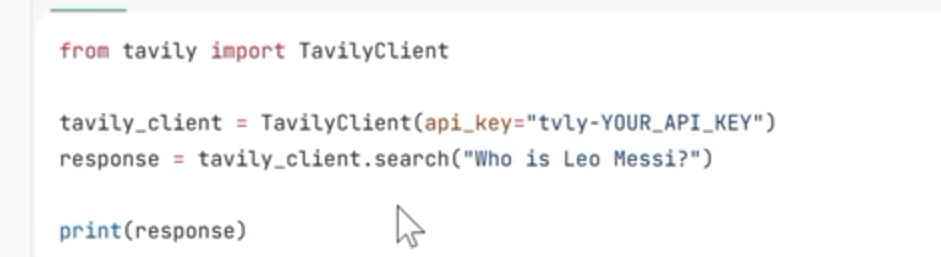

In [ ]:
"""
·注册账号，创建APIKEY
·配置环境变量:TAVILY_API_KEY
·安装依赖：uv add langchain-tavily
"""